In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import functional as F
from sklearn.model_selection import train_test_split
import copy
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

In [2]:
# Configuration
IMAGES_DIR = "/home/Joshua/Downloads/leopard_toad_identification/dataset/detect_2/dataset_clahe/images"
LABELS_DIR = "/home/Joshua/Downloads/leopard_toad_identification/dataset/detect_2/dataset_clahe/labels"
BATCH_SIZE = 8
EPOCHS = 30
LR = 0.005  # Standard starting LR for Faster R-CNN
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0005

DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [3]:
# BLOCK 2: AUGMENTATION PIPELINES
def get_train_transform():
    return A.Compose(
        [
            # 1. Geometric: Flip left/right (Toads can face either way)
            A.HorizontalFlip(p=0.5),
            # 2. Photometric: Simulate Flash/Night variations
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
            # 3. Quality: Simulate out-of-focus cameras or moving toads
            A.OneOf(
                [
                    A.MotionBlur(blur_limit=5, p=1.0),
                    A.GaussianBlur(blur_limit=(3, 7), p=1.0),
                ],
                p=0.3,
            ),
            # 4. Noise: Simulate high ISO IR sensor noise
            A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
            # 5. Format for PyTorch (Normalizes to 0-1 scale)
            A.ToFloat(max_value=255.0),
            ToTensorV2(),
        ],
        bbox_params=A.BboxParams(format="pascal_voc", label_fields=["class_labels"]),
    )


def get_val_transform():
    # Validation only scales the image and converts to Tensor. No distortions!
    return A.Compose(
        [A.ToFloat(max_value=255.0), ToTensorV2()],
        bbox_params=A.BboxParams(format="pascal_voc", label_fields=["class_labels"]),
    )

In [4]:
# BLOCK 3: DATASET AND DATALOADERS (UPDATED)
class WLTDataset(Dataset):
    def __init__(self, image_files, images_dir, labels_dir, transforms=None):
        self.image_files = image_files
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # 1. Load Image using OpenCV (Albumentations prefers numpy arrays)
        img_name = self.image_files[idx]
        img_path = os.path.join(self.images_dir, img_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB
        h, w, _ = image.shape

        # 2. Load Labels
        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(self.labels_dir, label_name)

        boxes = []
        labels = []

        if os.path.exists(label_path) and os.path.getsize(label_path) > 0:
            with open(label_path, "r") as f:
                for line in f.readlines():
                    class_id, x_center, y_center, width, height = map(
                        float, line.strip().split()
                    )

                    # Convert YOLO to Absolute Pixels (pascal_voc format)
                    xmin = (x_center - width / 2) * w
                    ymin = (y_center - height / 2) * h
                    xmax = (x_center + width / 2) * w
                    ymax = (y_center + height / 2) * h

                    # Strictly clamp to image boundaries to prevent Augmentation errors
                    xmin = max(0.0, xmin)
                    ymin = max(0.0, ymin)
                    xmax = min(float(w - 1.0), xmax)
                    ymax = min(float(h - 1.0), ymax)

                    if xmax > xmin and ymax > ymin:
                        boxes.append([xmin, ymin, xmax, ymax])
                        # Faster R-CNN requires Class 0 = Background
                        labels.append(int(class_id) + 1)

        # 3. Apply Augmentations
        if self.transforms is not None:
            transformed = self.transforms(
                image=image, bboxes=boxes, class_labels=labels
            )
            image = transformed["image"]
            boxes = transformed["bboxes"]
            labels = transformed["class_labels"]

        # 4. Format into PyTorch Tensors
        if len(boxes) > 0:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["image_id"] = torch.tensor([idx])

        return image, target

In [5]:
# --- DATALOADER SETUP ---
def collate_fn(batch):
    return tuple(zip(*batch))


all_images = [
    f for f in os.listdir(IMAGES_DIR) if f.lower().endswith((".png", ".jpg", ".jpeg"))
]
train_imgs, val_imgs = train_test_split(all_images, test_size=0.2, random_state=42)

print(f"Training images: {len(train_imgs)}")
print(f"Validation images: {len(val_imgs)}")

# Apply the Train augmentations to the training set, and Val to the validation set
train_dataset = WLTDataset(
    train_imgs, IMAGES_DIR, LABELS_DIR, transforms=get_train_transform()
)
val_dataset = WLTDataset(
    val_imgs, IMAGES_DIR, LABELS_DIR, transforms=get_val_transform()
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn,
)

Training images: 204
Validation images: 51


/tmp/ipykernel_174079/981527166.py:17: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
/home/Joshua/Downloads/leopard_toad_identification/.venv/lib/python3.12/site-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


In [6]:
# BLOCK 4: MODEL SETUP
def get_model(num_classes):
    # 1. Load pre-trained Faster R-CNN
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

    # 2. Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # 3. Replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model


# Number of classes = 4 (Background + WLT + Other_Frog + Mammal)
NUM_CLASSES = 4
model = get_model(NUM_CLASSES)
model.to(DEVICE)

# Define Optimizer and Learning Rate Scheduler
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)

# Reduce LR by 10x every 10 epochs
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [7]:
# BLOCK 5: TRAINING LOOP
history = {"train_loss": [], "val_loss": []}
best_val_loss = float("inf")
best_model_wts = copy.deepcopy(model.state_dict())

os.makedirs("weights", exist_ok=True)

print("Starting Faster R-CNN Training...")

for epoch in range(EPOCHS):
    # ==============================
    # 1. TRAINING PHASE
    # ==============================
    model.train()
    train_loss_accum = 0.0

    for images, targets in train_loader:
        images = list(image.to(DEVICE) for image in images)
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        # Faster R-CNN returns a dictionary of losses
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        train_loss_accum += losses.item()

    avg_train_loss = train_loss_accum / len(train_loader)

    # ==============================
    # 2. VALIDATION PHASE
    # ==============================
    # Note: To get validation loss, the model must remain in .train() mode,
    # but we use torch.no_grad() so we don't update weights.
    val_loss_accum = 0.0

    with torch.no_grad():
        for images, targets in val_loader:
            images = list(image.to(DEVICE) for image in images)
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            val_loss_accum += losses.item()

    avg_val_loss = val_loss_accum / len(val_loader)

    # Update Learning Rate
    lr_scheduler.step()

    # ==============================
    # 3. LOGGING & SAVING
    # ==============================
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}"
    )

    # Save Best Model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(
            model.state_dict(),
            "/home/Joshua/Downloads/leopard_toad_identification/detection/weights/best_faster_rcnn.pth",
        )
        print("  --> Best Model Saved!")

print("Training Complete!")

Starting Faster R-CNN Training...
Epoch [1/30] | Train Loss: 0.1922 | Val Loss: 0.0878
  --> Best Model Saved!
Epoch [2/30] | Train Loss: 0.0914 | Val Loss: 0.0675
  --> Best Model Saved!
Epoch [3/30] | Train Loss: 0.0669 | Val Loss: 0.0474
  --> Best Model Saved!
Epoch [4/30] | Train Loss: 0.0502 | Val Loss: 0.0426
  --> Best Model Saved!
Epoch [5/30] | Train Loss: 0.0421 | Val Loss: 0.0409
  --> Best Model Saved!
Epoch [6/30] | Train Loss: 0.0346 | Val Loss: 0.0341
  --> Best Model Saved!
Epoch [7/30] | Train Loss: 0.0340 | Val Loss: 0.0346
Epoch [8/30] | Train Loss: 0.0347 | Val Loss: 0.0295
  --> Best Model Saved!
Epoch [9/30] | Train Loss: 0.0306 | Val Loss: 0.0319
Epoch [10/30] | Train Loss: 0.0340 | Val Loss: 0.0285
  --> Best Model Saved!
Epoch [11/30] | Train Loss: 0.0249 | Val Loss: 0.0296
Epoch [12/30] | Train Loss: 0.0231 | Val Loss: 0.0285
Epoch [13/30] | Train Loss: 0.0225 | Val Loss: 0.0282
  --> Best Model Saved!
Epoch [14/30] | Train Loss: 0.0239 | Val Loss: 0.0272
  -

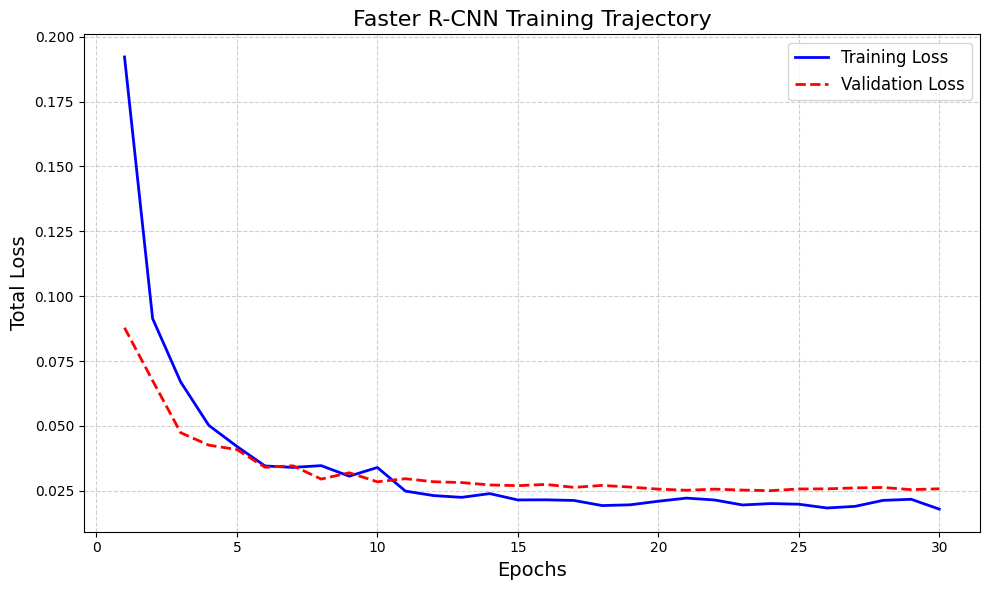

In [8]:
# BLOCK 6: PLOT LOSS TRAJECTORY
def plot_training_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history["train_loss"], "b-", label="Training Loss", linewidth=2)
    plt.plot(epochs, history["val_loss"], "r--", label="Validation Loss", linewidth=2)

    plt.title("Faster R-CNN Training Trajectory", fontsize=16)
    plt.xlabel("Epochs", fontsize=14)
    plt.ylabel("Total Loss", fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()


plot_training_history(history)

Evaluating model on validation set to generate curves...


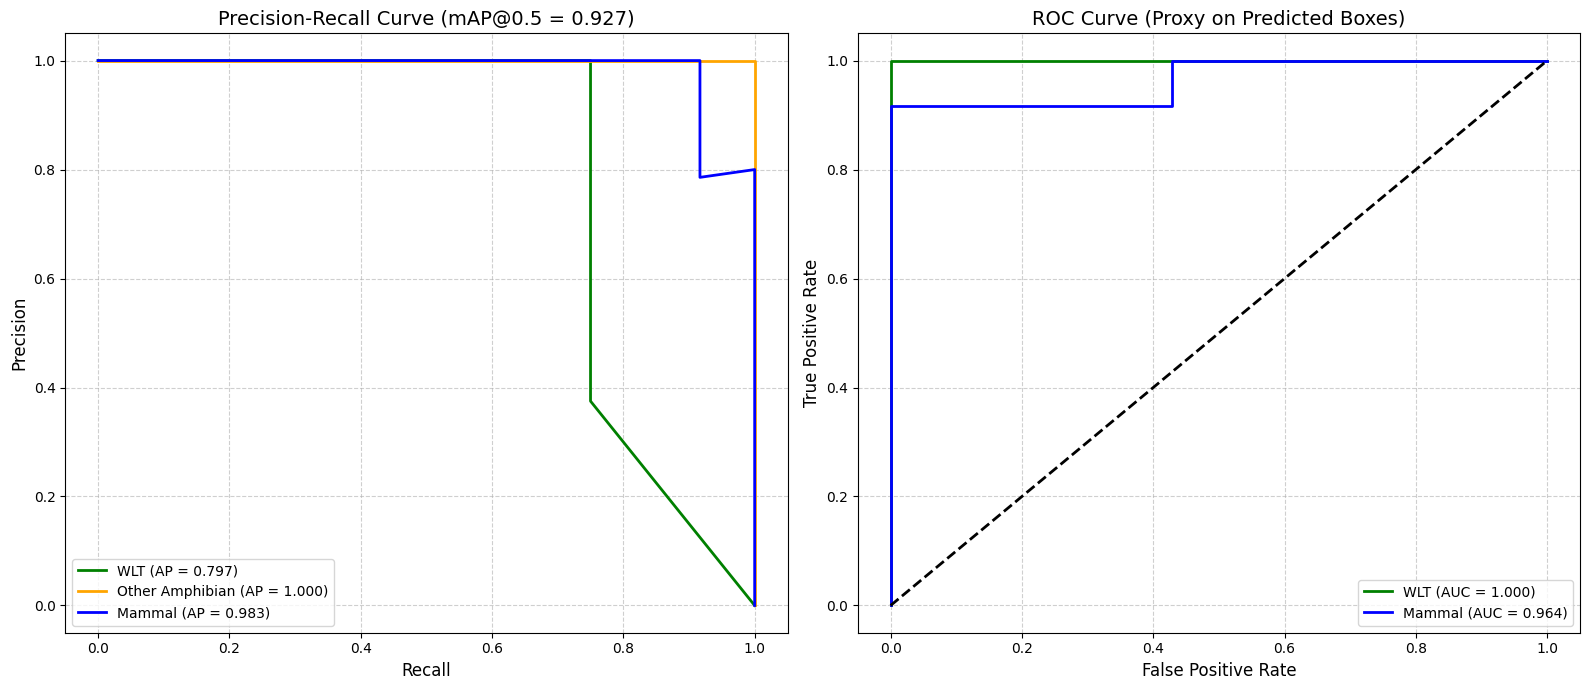

In [ ]:
# BLOCK 8: PR & ROC-AUC CURVES (EVALUATION)
import torchvision.ops.boxes as box_ops
from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    auc,
    average_precision_score,
)


def evaluate_and_plot_curves(model, val_loader, device, iou_threshold=0.5):
    print("Evaluating model on validation set to generate curves...")
    model.eval()

    # Dictionaries to hold ground truth counts and prediction data per class
    # Class IDs: 1 (WLT), 2 (Other_Frog), 3 (Mammal)
    classes = [1, 2, 3]
    gt_counts = {c: 0 for c in classes}

    # Store tuples of (score, is_true_positive)
    predictions_data = {c: [] for c in classes}

    with torch.no_grad():
        for images, targets in val_loader:
            images = list(img.to(device) for img in images)
            outputs = model(images)

            for output, target in zip(outputs, targets):
                gt_boxes = target["boxes"].to(device)
                gt_labels = target["labels"].to(device)

                pred_boxes = output["boxes"].to(device)
                pred_labels = output["labels"].to(device)
                pred_scores = output["scores"].to(device)

                # Tally total Ground Truths per class
                for c in classes:
                    gt_counts[c] += (gt_labels == c).sum().item()

                # Match Predictions to GT per class
                for c in classes:
                    c_gt_boxes = gt_boxes[gt_labels == c]
                    c_pred_mask = pred_labels == c
                    c_pred_boxes = pred_boxes[c_pred_mask]
                    c_pred_scores = pred_scores[c_pred_mask]

                    # Sort predictions by score descending
                    sort_idx = torch.argsort(c_pred_scores, descending=True)
                    c_pred_boxes = c_pred_boxes[sort_idx]
                    c_pred_scores = c_pred_scores[sort_idx]

                    matched_gt = set()  # Track which GT boxes have been "claimed"

                    for i in range(len(c_pred_boxes)):
                        score = c_pred_scores[i].item()
                        is_tp = 0

                        if len(c_gt_boxes) > 0:
                            # Calculate IoU with all GT boxes of this class
                            ious = box_ops.box_iou(
                                c_pred_boxes[i].unsqueeze(0), c_gt_boxes
                            )[0]
                            max_iou, max_idx = ious.max(0)
                            max_idx = max_idx.item()

                            if max_iou >= iou_threshold and max_idx not in matched_gt:
                                is_tp = 1
                                matched_gt.add(max_idx)  # Claim this GT box

                        predictions_data[c].append((score, is_tp))

    # --- PLOTTING ---
    fig, (ax_pr, ax_roc) = plt.subplots(1, 2, figsize=(16, 7))
    class_names = {1: "WLT", 2: "Other Amphibian", 3: "Mammal"}
    colors = {1: "green", 2: "orange", 3: "blue"}

    mean_ap = 0.0

    for c in classes:
        if gt_counts[c] == 0:
            continue

        # Sort data by score descending
        data = sorted(predictions_data[c], key=lambda x: x[0], reverse=True)
        scores = [x[0] for x in data]
        tps = [x[1] for x in data]
        fps = [1 - x for x in tps]

        # Cumulative sums
        cum_tps = np.cumsum(tps)
        cum_fps = np.cumsum(fps)

        # PR Curve Math
        recalls = cum_tps / gt_counts[c]
        precisions = cum_tps / (cum_tps + cum_fps + 1e-16)

        # Append 0/1 bounds for clean plotting
        recalls = np.concatenate(([0.0], recalls, [1.0]))
        precisions = np.concatenate(([1.0], precisions, [0.0]))

        # Calculate AP (Area Under PR Curve)
        ap = auc(recalls, precisions)
        mean_ap += ap

        # Plot PR
        ax_pr.plot(
            recalls,
            precisions,
            color=colors[c],
            lw=2,
            label=f"{class_names[c]} (AP = {ap:.3f})",
        )

        if sum(fps) > 0:
            fpr, tpr, _ = roc_curve(tps, scores)
            roc_auc = auc(fpr, tpr)
            ax_roc.plot(
                fpr,
                tpr,
                color=colors[c],
                lw=2,
                label=f"{class_names[c]} (AUC = {roc_auc:.3f})",
            )

    # Finalize PR Plot
    ax_pr.set_title(
        f"Precision-Recall Curve (mAP@0.5 = {mean_ap / len(classes):.3f})", fontsize=14
    )
    ax_pr.set_xlabel("Recall", fontsize=12)
    ax_pr.set_ylabel("Precision", fontsize=12)
    ax_pr.legend(loc="lower left", fontsize=10)
    ax_pr.grid(True, linestyle="--", alpha=0.6)

    # Finalize ROC Plot
    ax_roc.plot([0, 1], [0, 1], color="black", lw=2, linestyle="--")
    ax_roc.set_title("ROC Curve (Proxy on Predicted Boxes)", fontsize=14)
    ax_roc.set_xlabel("False Positive Rate", fontsize=12)
    ax_roc.set_ylabel("True Positive Rate", fontsize=12)
    ax_roc.legend(loc="lower right", fontsize=10)
    ax_roc.grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.savefig(
        "/home/Joshua/Downloads/leopard_toad_identification/detection/evaluation_curves.png",
        dpi=300,
    )
    plt.show()


# Run the evaluation
evaluate_and_plot_curves(model, val_loader, DEVICE, iou_threshold=0.5)

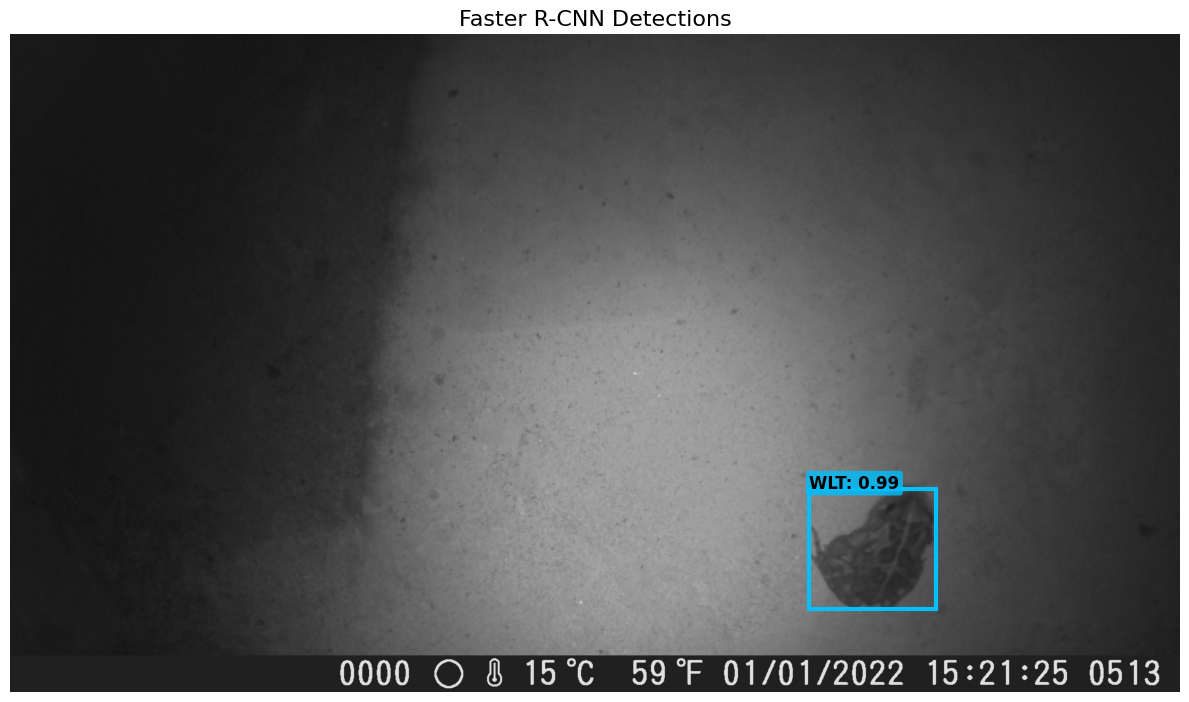

In [10]:
# BLOCK 7: INFERENCE & VISUALIZATION
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import torch
from torchvision.transforms import functional as F
from PIL import Image

# 1. Setup Configuration
CONF_THRESH = 0.5  # Only show boxes with confidence > 50%
CLASS_NAMES = {3: "WLT", 2: "Other_Frog", 1: "Mammal"}
COLORS = {1: "#00FF00", 2: "#FFA500", 3: "#00BFFF"}  # Green, Orange, Blue

# 2. Load Model & Image
model.load_state_dict(
    torch.load(
        "/home/Joshua/Downloads/leopard_toad_identification/detection/weights/best_faster_rcnn.pth",
        map_location=DEVICE,
    )
)
model.eval()

img_path = (
    "/srv/shared_leopard_toad/2023/Cameras - AI Data/Observed/Seen/5z-100 (389).JPG"
)
img = Image.open(img_path).convert("RGB")
img_tensor = F.to_tensor(img).unsqueeze(0).to(DEVICE)

# 3. Predict
with torch.no_grad():
    predictions = model(img_tensor)[0]  # Extract the first (and only) image result

# 4. Extract outputs to CPU
boxes = predictions["boxes"].cpu().numpy()
labels = predictions["labels"].cpu().numpy()
scores = predictions["scores"].cpu().numpy()

# 5. Plotting
fig, ax = plt.subplots(1, figsize=(12, 8))
ax.imshow(img)

for box, label, score in zip(boxes, labels, scores):
    if score >= CONF_THRESH:
        xmin, ymin, xmax, ymax = box
        width, height = xmax - xmin, ymax - ymin

        class_name = CLASS_NAMES.get(label, "Unknown")
        color = COLORS.get(label, "red")

        # Draw Bounding Box
        rect = patches.Rectangle(
            (xmin, ymin), width, height, linewidth=3, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)

        # Draw Label Text Background
        label_text = f"{class_name}: {score:.2f}"
        ax.text(
            xmin,
            ymin - 5,
            label_text,
            color="black",
            fontsize=12,
            fontweight="bold",
            bbox=dict(
                facecolor=color, alpha=0.8, edgecolor="none", boxstyle="round,pad=0.2"
            ),
        )

plt.title("Faster R-CNN Detections", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()